# Домашнее задание: Оценка разницы средних с помощью бутстрепа

## Контекст

Компания использует программу лояльности, разделяя пользователей на два сегмента:

- **VIP** — высоко вовлечённые пользователи
- **NonVIP** — остальные пользователи

Менеджеры утверждают, что **VIP-пользователи тратят существенно больше**, чем остальные.  
Ваша задача — **оценить разницу их среднего расхода** корректно и аккуратно, учитывая, что распределения расходов могут иметь **тяжёлые хвосты** (редкие покупатели с очень высокими тратами).

У вас есть данные:

| user_id | segment | total_spend |
|--------:|---------|-------------:|
| 1       | VIP     |       12800  |
| 2       | NonVIP  |         900  |
| 3       | VIP     |        6400  |
| ...     | ...     |         ...  |

`total_spend` — сумма покупок пользователя за последний квартал.

## Задача

1. Построить **95% доверительный интервал для Δ**:

   - с использованием **наивного бутстрепа**
   - с использованием **пуассоновского бутстрепа**

2. Построить распределения оценок Δ:
   - две гистограммы / KDE на одном графике

3. Сравнить методы:
   - отличаются ли ширины интервалов?
   - симметричны ли распределения оценок?
   - заметно ли влияние редких крупных трат у VIP?

4. Написать **не технический вывод (2–4 предложения)**:
   - Можно ли с уверенностью утверждать, что VIP тратят больше?
   - Насколько результат устойчив?
   - Есть ли риск «искажения» за счёт нескольких очень дорогих покупок?

## Что сдавать

- Код расчёта и построения бутстреп-интервалов
- Графики распределений оценок Δ
- Краткий аналитический вывод

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df = pd.read_csv('hm1.csv')
print(df.describe())
print(df.info())

            user_id   total_spend
count  23000.000000  23000.000000
mean   11499.500000    943.509026
std     6639.672432   1056.439343
min        0.000000     41.582018
25%     5749.750000    473.789228
50%    11499.500000    699.865661
75%    17249.250000   1062.119375
max    22999.000000  41389.502285
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23000 entries, 0 to 22999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_id      23000 non-null  int64  
 1   segment      23000 non-null  object 
 2   total_spend  23000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 539.2+ KB
None


In [9]:
vip = df[df['segment'] == 'VIP']['total_spend'].values
nonvip = df[df['segment'] == 'NonVIP']['total_spend'].values

print("VIP size:", len(vip))
print("NonVIP size:", len(nonvip))

delta_hat = vip.mean() - nonvip.mean()
print("Observed Δ:", delta_hat)

VIP size: 3000
NonVIP size: 20000
Observed Δ: 1278.2567223154756


In [10]:
# Наивный бутстрап
def naive_bootstrap(vip, nonvip, B=10000, random_state=42):
    np.random.seed(random_state)
    deltas = []

    for _ in range(B):
        vip_sample = np.random.choice(vip, size=len(vip), replace=True)
        nonvip_sample = np.random.choice(nonvip, size=len(nonvip), replace=True)
        deltas.append(vip_sample.mean() - nonvip_sample.mean())

    return np.array(deltas)

naive_deltas = naive_bootstrap(vip, nonvip)

ci_naive = np.percentile(naive_deltas, [2.5, 97.5])
print("Naive bootstrap 95% CI:", ci_naive)

Naive bootstrap 95% CI: [1194.05423244 1365.47336543]


In [11]:
# Пуассоновский бутстрап
def poisson_bootstrap(vip, nonvip, B=10000, random_state=42):
    np.random.seed(random_state)
    deltas = []

    n_vip = len(vip)
    n_nonvip = len(nonvip)

    for _ in range(B):
        w_vip = np.random.poisson(1, n_vip)
        w_nonvip = np.random.poisson(1, n_nonvip)

        # избегаем деления на ноль
        if w_vip.sum() == 0 or w_nonvip.sum() == 0:
            continue

        vip_mean = np.sum(w_vip * vip) / w_vip.sum()
        nonvip_mean = np.sum(w_nonvip * nonvip) / w_nonvip.sum()

        deltas.append(vip_mean - nonvip_mean)

    return np.array(deltas)

poisson_deltas = poisson_bootstrap(vip, nonvip)

ci_poisson = np.percentile(poisson_deltas, [2.5, 97.5])
print("Poisson bootstrap 95% CI:", ci_poisson)


Poisson bootstrap 95% CI: [1192.60074422 1367.06353893]


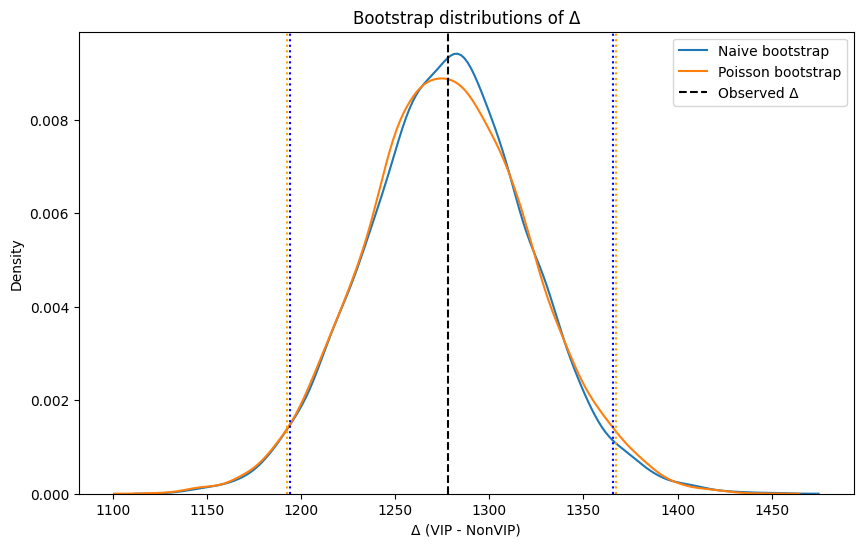

In [12]:
plt.figure(figsize=(10,6))

sns.kdeplot(naive_deltas, label='Naive bootstrap')
sns.kdeplot(poisson_deltas, label='Poisson bootstrap')

plt.axvline(delta_hat, color='black', linestyle='--', label='Observed Δ')
plt.axvline(ci_naive[0], color='blue', linestyle=':')
plt.axvline(ci_naive[1], color='blue', linestyle=':')
plt.axvline(ci_poisson[0], color='orange', linestyle=':')
plt.axvline(ci_poisson[1], color='orange', linestyle=':')

plt.legend()
plt.title("Bootstrap distributions of Δ")
plt.xlabel("Δ (VIP - NonVIP)")
plt.ylabel("Density")
plt.show()

### Вывод

Ширины 95% CI практически совпадают: для наивного бутстрэпа [1194;1365], для пуассоновского [1193;1367]. Разница в ширине интервалов несущественна (порядка нескольких единиц), что говорит о стабильности оценки и близости дисперсий в двух подходах.

Распределения бутстреп-оценок Δ в обоих случаях близки к нормальным и симметричным относительно наблюдаемого значения (~1278). Явной асимметрии или длинного правого хвоста не наблюдается. Это указывает на то, что влияние тяжёлых хвостов (редких крупных трат) не приводит к сильному перекосу распределения разности средних.

Влияние редких крупных трат в сегменте VIP заметно ограничено: если бы несколько экстремально дорогих покупок существенно искажали оценку, мы ожидали бы более широкий интервал и выраженную правостороннюю асимметрию. Поскольку этого не наблюдается, эффект крупных выбросов не является доминирующим.

С высокой степенью уверенности можно утверждать, что VIP-пользователи тратят больше: 95% доверительный интервал полностью лежит выше нуля и составляет примерно от 1190 до 1370 денежных единиц. Разница в среднем чеке между сегментами статистически и практически значима (~1278).

Результат устойчив: два различных варианта бутстрэпа дают почти идентичные оценки и интервалы. Риск искажения вывода за счёт нескольких очень дорогих покупок невысок — распределение оценок симметрично, а ширина интервала умеренная. Таким образом, утверждение менеджеров о более высоких тратах VIP-пользователей подтверждается данными.